<a href="https://colab.research.google.com/github/amrita13/LanchesterModelOnKurskData/blob/main/Lanchester_Square_Linear_KurskData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tank dataset saved to kursk_tank_data.csv
Estimated coefficients based on average daily losses:
a = 0.05774521586172897
b = 0.2930144326182474


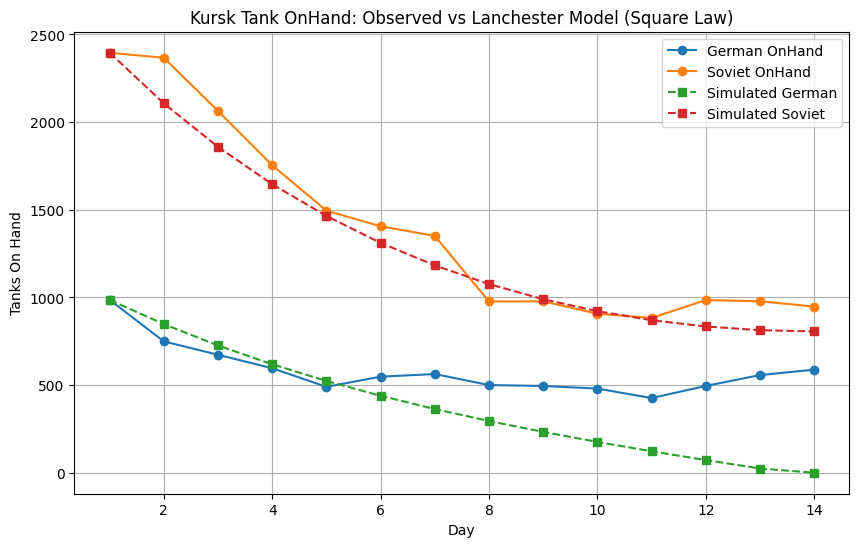

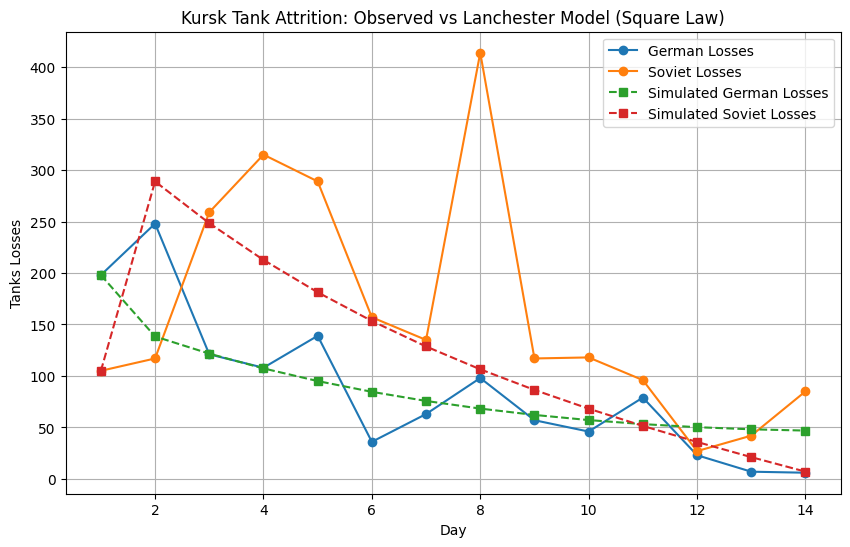

Estimated coefficients based on average daily losses:
a = 0.007583937341166888
b = 0.015998234918001782


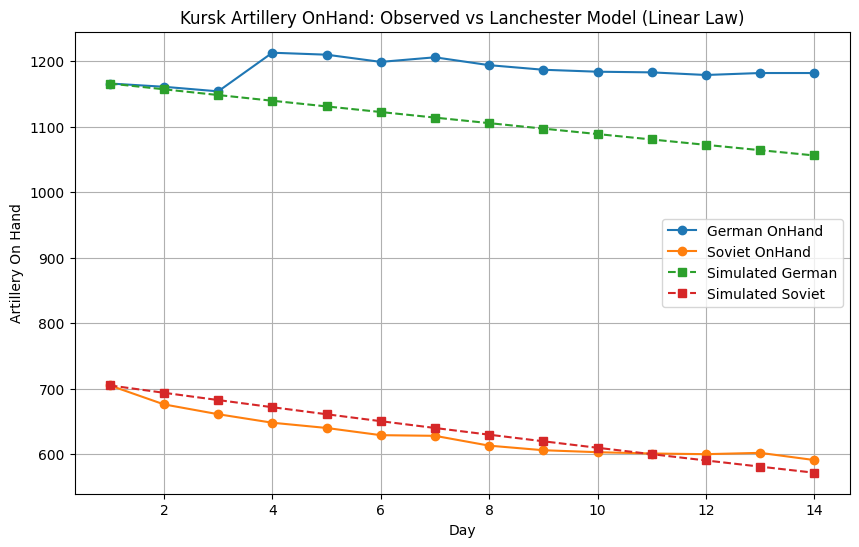

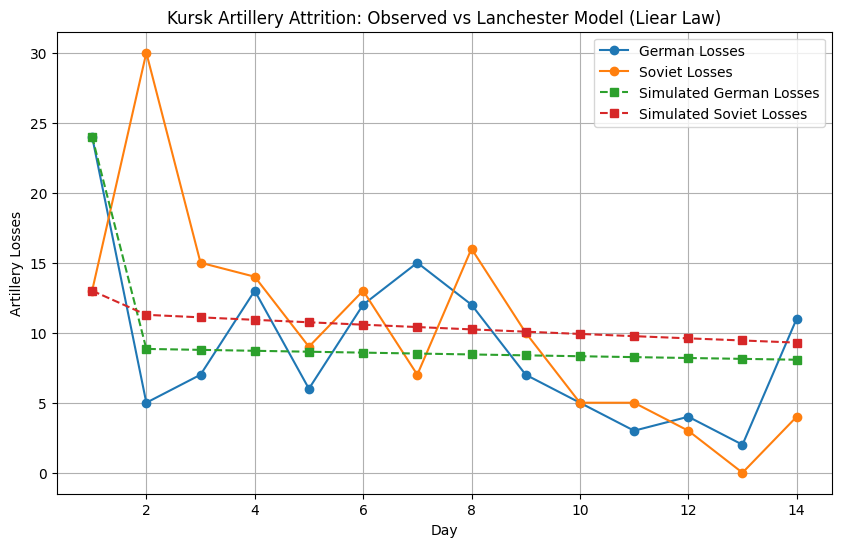

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Create tank dataset
# -------------------------------
data = {
    'Day': list(range(1, 15)),
    'German_OnHand': [986,  749,    673,    596,    490,    548,    563,    500,    495,    480,    426,    495,    557,    588],
    'German_Losses': [198,  248,    121,    108,    139,    36,     63,     98,     57,     46,     79,     23,     7,      6],
    'Soviet_OnHand': [2396, 2367,   2064,   1754,   1495,   1406,   1351,   977,    978,    907,    883,    985,    978,    948],
    'Soviet_Losses': [105,  117,    259,    315,    289,    157,    135,    414,    117,    118,    96,     27,     42,     85],
    #Artillery Data
    'German_Artillery_OnHand': [1166,	1161,	1154,	1213,	1210,	1199,	1206,	1194,	1187,	1184,	1183,	1179,	1182,	1182],
    'German_Artillery_Losses': [24,	5,	7,	13,	6,	12,	15,	12,	7,	5, 3,	4,	2,	11],
    'Soviet_Artillery_OnHand': [705,	676,	661,	648,	640,	629,	628,	613,	606,	603,	601,	600,	602,	591],
    'Soviet_Artillery_Losses': [13,	30,	15,	14,	9,	13,	7,	16,	10,	5,	5,	3,	0,	4]



}
df = pd.DataFrame(data)
# Save dataset to CSV
df.to_csv("kursk_tank_data.csv", index=False)
print("Tank dataset saved to kursk_tank_data.csv")
# -------------------------------
# Step 2: Define Lanchester model
# -------------------------------
def lanchester_model(G0, S0,G_loss,S_loss, a, b, days):
    """
    Simple Lanchester square-law model:
    dG/dt = -a * S
    dS/dt = -b * G
    """
    G = [G0]
    S = [S0]
    G_loss=[G_loss]
    S_loss=[S_loss]
    for t in range(1, days):
        dG = -a * S[-1]
        dS = -b * G[-1]
        G.append(max(G[-1] + dG, 0))
        S.append(max(S[-1] + dS, 0))
        # G_loss.append(max(G_loss[-1] + dG,-1000))
        # S_loss.append(max(S_loss[-1] + dS,-1000))
        G_loss.append(-dG)
        S_loss.append(-dS)
    return np.array(G), np.array(S), np.array(G_loss), np.array(S_loss)

#   For Tank vs Tank Battle-----------------------------------------
# -------------------------------
# Step 3: Estimate coefficients
# -------------------------------
# Estimate daily coefficients
df['a_daily'] = df['German_Losses'] / df['Soviet_OnHand']
df['b_daily'] = df['Soviet_Losses'] / df['German_OnHand']
# Average coefficients
a_est = df['a_daily'].mean()
b_est = df['b_daily'].mean()
print("Estimated coefficients based on average daily losses:")
print("a =", a_est)
print("b =", b_est)
# -------------------------------
# Step 3: Run simulation
# -------------------------------
a,b=a_est,b_est
# a, b = 0.00000005, 0.000000004   # illustrative coefficients
G_sim, S_sim,G_loss,S_loss = lanchester_model(986, 2396, 198,105,a, b, 14)
# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['German_OnHand'], 'o-', label='German OnHand')
plt.plot(df['Day'], df['Soviet_OnHand'], 'o-', label='Soviet OnHand')
plt.plot(df['Day'], G_sim, 's--', label='Simulated German')
plt.plot(df['Day'], S_sim, 's--', label='Simulated Soviet')
plt.xlabel('Day')
plt.ylabel('Tanks On Hand')
plt.title('Kursk Tank OnHand: Observed vs Lanchester Model (Square Law)')
plt.legend()
plt.grid(True)
plt.show()
# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['German_Losses'], 'o-', label='German Losses')
plt.plot(df['Day'], df['Soviet_Losses'], 'o-', label='Soviet Losses')
plt.plot(df['Day'], G_loss, 's--', label='Simulated German Losses')
plt.plot(df['Day'], S_loss, 's--', label='Simulated Soviet Losses')
plt.xlabel('Day')
plt.ylabel('Tanks Losses')
plt.title('Kursk Tank Attrition: Observed vs Lanchester Model (Square Law)')
plt.legend()
plt.grid(True)
plt.show()
#   For Tank vs Tank Battle-----------------------------------------

def lanchester_linear_model(G0, S0,G_loss,S_loss, a, b, days):
    """
    Simple Lanchester square-law model:
    dG/dt = -a * G
    dS/dt = -b * S
    """
    G = [G0]
    S = [S0]
    G_loss=[G_loss]
    S_loss=[S_loss]
    for t in range(1, days):
        dG = -a * G[-1]
        dS = -b * S[-1]
        G.append(max(G[-1] + dG, 0))
        S.append(max(S[-1] + dS, 0))
        # G_loss.append(max(G_loss[-1] + dG,-1000))
        # S_loss.append(max(S_loss[-1] + dS,-1000))
        G_loss.append(-dG)
        S_loss.append(-dS)
    return np.array(G), np.array(S), np.array(G_loss), np.array(S_loss)

#   For Artillery vs Artillery Battle-----------------------------------------
# -------------------------------
# Step 3: Estimate coefficients
# -------------------------------
# Estimate daily coefficients
df['a_daily'] = df['German_Artillery_Losses'] / df['German_Artillery_OnHand']
df['b_daily'] = df['Soviet_Artillery_Losses'] / df['Soviet_Artillery_OnHand']
# Average coefficients
a_est = df['a_daily'].mean()
b_est = df['b_daily'].mean()
print("Estimated coefficients based on average daily losses:")
print("a =", a_est)
print("b =", b_est)
# -------------------------------
# Step 3: Run simulation
# -------------------------------
a,b=a_est,b_est
# a, b = 0.00000005, 0.000000004   # illustrative coefficients
G_sim, S_sim,G_loss,S_loss = lanchester_linear_model(1166, 705, 24,13,a, b, 14)
# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['German_Artillery_OnHand'], 'o-', label='German OnHand')
plt.plot(df['Day'], df['Soviet_Artillery_OnHand'], 'o-', label='Soviet OnHand')
plt.plot(df['Day'], G_sim, 's--', label='Simulated German')
plt.plot(df['Day'], S_sim, 's--', label='Simulated Soviet')
plt.xlabel('Day')
plt.ylabel('Artillery On Hand')
plt.title('Kursk Artillery OnHand: Observed vs Lanchester Model (Linear Law)')
plt.legend()
plt.grid(True)
plt.show()
# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['German_Artillery_Losses'], 'o-', label='German Losses')
plt.plot(df['Day'], df['Soviet_Artillery_Losses'], 'o-', label='Soviet Losses')
plt.plot(df['Day'], G_loss, 's--', label='Simulated German Losses')
plt.plot(df['Day'], S_loss, 's--', label='Simulated Soviet Losses')
plt.xlabel('Day')
plt.ylabel('Artillery Losses')
plt.title('Kursk Artillery Attrition: Observed vs Lanchester Model (Liear Law)')
plt.legend()
plt.grid(True)
plt.show()
#   For Artillery vs Artillery Battle-----------------------------------------

